In [1]:
import numpy as np
import pandas as pd
import optuna
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Загрузим данные

- Данные упорядочены по времени
- Задача - предсказать `target`
- Фичи - `feature_i`
- Трейн, валидация и тест уже определены (см. колонку `sample_part`)

In [2]:
df = pd.read_parquet('df.parquet.gzip')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 22620 to 310653
Columns: 235 entries, date to sample_part
dtypes: category(2), datetime64[ms](1), datetime64[ns](2), float64(220), int64(9), object(1)
memory usage: 893.6+ MB


In [3]:
df.head()

,date,month,quarter,feature_217,feature_66,feature_9,feature_193,feature_15,feature_199,feature_25,...,feature_20,feature_188,feature_71,feature_106,feature_14,feature_92,feature_179,feature_102,target,sample_part
22620,2021-01-01,2021-01-01,2021-01-01,1.180855,0.483118,13.976791,1.135021,43.271792,-46.888875,97.558366,...,23.745198,-32.001093,85.489903,1.454045,-195.725786,3.719083,1,-28.813537,0.0,train
478621,2021-01-01,2021-01-01,2021-01-01,3.427814,0.886778,27.158209,-0.378728,80.087863,-67.242703,105.803406,...,22.902111,-37.436243,71.735619,1.657242,-176.250404,3.277817,1,-45.987721,1.0,train
372254,2021-01-01,2021-01-01,2021-01-01,-38.555018,1.227175,19.893873,0.498787,98.464365,-67.402522,81.858076,...,21.848414,-51.872841,65.363236,1.626874,-178.116798,2.028950,0,-31.074122,1.0,train
2596,2021-01-01,2021-01-01,2021-01-01,-14.666558,0.753129,18.203010,-1.200014,117.331340,-25.557745,90.277266,...,26.134586,-49.703003,65.013659,1.170023,-192.232264,2.218177,1,-36.703897,0.0,train
216892,2021-01-01,2021-01-01,2021-01-01,6.734990,1.129100,11.245920,-0.108955,61.205722,-78.397406,82.637472,...,24.201039,-41.070219,69.986127,1.630795,-200.155528,3.055104,1,-44.672299,1.0,train


In [4]:
TARGET = 'target'
N_FEATURES = 230
features = [f'feature_{i}' for i in range(N_FEATURES)]

In [5]:
df[TARGET].head()

22620     0.0
478621    1.0
372254    1.0
2596      0.0
216892    1.0
Name: target, dtype: float64

In [6]:
df[TARGET].value_counts(dropna=False)

target
1.0    354855
0.0    145145
Name: count, dtype: int64

# Первичный отбор признаков... (1 балл)

**Задание:** Сначала отсеем совсем уж мусорные признаки.

Воспользовавшись вашим кодом для вычисления `IV` из прошлой домашки, для всех **числовых** фичей вычислите `IV` на 20 бакетах. Отсейте признаки с `IV < 0.005`.

**Hint:** паркет не всегда сохраняет `dtype` колонки. Чтобы проверить признаки на "реальный" тип данных, лучше на всякий случай посмотреть на `nunique` 

In [7]:
def calc_iv(data, feature, target, n_buckets=20, is_categorical=False):
    x = data[feature]
    y = data[target]
    mask = x.notna()

    bucket = pd.Series(index=x.index, dtype=object)
    if is_categorical:
        bucket[mask] = x[mask].astype(str)
    else:
        bucket[mask] = pd.qcut(x[mask], q=n_buckets, duplicates='drop').astype(str)
    bucket[~mask] = 'MISSING'

    temporary_dataframe = pd.DataFrame({'bucket': bucket, 'y': y})
    grouped_bucket = temporary_dataframe.groupby('bucket')['y'].agg(['count', 'sum'])
    grouped_bucket.columns = ['total', 'bad']
    grouped_bucket['good'] = grouped_bucket['total'] - grouped_bucket['bad']

    total_bad, total_good = grouped_bucket['bad'].sum(), grouped_bucket['good'].sum()

    eps = 0.5  
    grouped_bucket['bad_rate'] = (grouped_bucket['bad'] + eps) / (total_bad + eps * len(grouped_bucket))
    grouped_bucket['good_rate'] = (grouped_bucket['good'] + eps) / (total_good + eps * len(grouped_bucket))
    grouped_bucket['woe'] = np.log(grouped_bucket['good_rate'] / grouped_bucket['bad_rate'])
    grouped_bucket['iv'] = (grouped_bucket['good_rate'] - grouped_bucket['bad_rate']) * grouped_bucket['woe']
    return grouped_bucket['iv'].sum()


train_data = df[df['sample_part'] == 'train']

numeric_features = [f for f in features if train_data[f].dtype != 'category']
categorical_features = [f for f in features if train_data[f].dtype == 'category']

iv_numeric = pd.Series({
    f: calc_iv(train_data, f, TARGET, n_buckets=20, is_categorical=False)
    for f in numeric_features
}).sort_values(ascending=False)

select_numeric = iv_numeric[iv_numeric >= 0.005].index.tolist()
print(f'Отобрано {len(select_numeric)} из {len(numeric_features)} числовых фичей')

Отобрано 59 из 228 числовых фичей


**Вопрос**: Почему некорректно сравнивать `IV` у категориальных и числовых фичей?

Вычислите IV для категориальных фичей на `n` бакетах, где `n = min(число категорий фичи, 20)`. Возможно, придётся перекодировать некоторые фичи (*только не OneHot-ом!*)

*Опционально*: примените также и к категориальным фичам предварительный отбор по `IV` с менее строгим порогом

In [8]:
print(train_data[categorical_features].nunique())

feature_0      4
feature_209    3
dtype: int64


In [9]:
categor_threshold = 0.001 

iv_categorical = pd.Series({
    f: calc_iv(train_data, f, TARGET, n_buckets=min(train_data[f].nunique(dropna=False), 20), is_categorical=True)
    for f in categorical_features
}).sort_values(ascending=False)

select_categorical = iv_categorical[iv_categorical >= categor_threshold].index.tolist()
print(f'Отобрано {len(select_categorical)} из {len(categorical_features)} категориальных фичей')

select_features = select_numeric + select_categorical
print(f'Всего отобранных фичей: {len(select_features)}')

Отобрано 1 из 2 категориальных фичей
Всего отобранных фичей: 60


Некорректно сравнивать, так как число IV сильно зависит от того, на сколько бакетов разделена фича. У числовых и категориальных фич число подбирается по-разному, поэтому их некорректно сравнивать напрямую. У числовых обычно 20 квантильных бакетов, а у категориальных подбирается по числу уникальных категорий, обычно до 20. Чем на большее количество бакетов мы бьём, тем больше вероятность случайно обнаружить сильные различия между долей плохих и хороших наблюдений или ложные совпадения. Фичи с большим числом бакетов обычно получают более высокий IV, так как случайные перекосы накапливаются и дают завышенный итоговый IV. Так, категориальная фича с несколькими категориями чаще проигрывает по IV числовой фиче на 20 бакетах. По сути для этого и ставится для категориальных фичей более мягкий порог. Важно подметить, что у обеих категориальных фичей уникальных значений меньше 20 (feature_0 у неё 4, а у feature_209 всего 3), поэтому min(nunique, 20) даёт само nunique, и каждая категория идёт отдельным бакетом, поэтому урезать ничего не пришлось.

# Бустинг

Используйте код для подбора гиперпараметров и обучения бустинга из предыдущей домашки

In [10]:
features_optuna = select_features

In [11]:
import lightgbm as lgb

In [12]:
import optuna

train_data = df[df['sample_part'] == 'train']
valid_data = df[df['sample_part'] == 'val']

RANDOM_STATE = 42

train_set = lgb.Dataset(train_data[features_optuna], label=train_data[TARGET])
valid_set = lgb.Dataset(valid_data[features_optuna], label=valid_data[TARGET], reference=train_set)


def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': RANDOM_STATE,
        'num_leaves': trial.suggest_int('num_leaves', 10, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    }

    model = lgb.train(
        params,
        train_set,
        num_boost_round=1000,
        valid_sets=[valid_set],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )

    preds = model.predict(valid_data[features_optuna], num_iteration=model.best_iteration)
    auc = roc_auc_score(valid_data[TARGET], preds)
    return auc


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50)

print("Best params:", study.best_params)
print("Best AUC:", study.best_value)

[I 2026-08-18 01:00:00,385] A new study created in memory with name: no-name-db0552ce-da51-417a-83b6-a8b7c1839de5
[I 2026-08-18 01:00:07,932] Trial 0 finished with value: 0.7353603152015541 and parameters: {'num_leaves': 81, 'learning_rate': 0.17254716573280354, 'feature_fraction': 0.8659969709057025, 'bagging_fraction': 0.759195090518222, 'bagging_freq': 2, 'lambda_l1': 2.5348407664333426e-07, 'lambda_l2': 3.3323645788192616e-08}. Best is trial 0 with value: 0.7353603152015541.
[I 2026-08-18 01:00:27,556] Trial 1 finished with value: 0.7453004730451676 and parameters: {'num_leaves': 175, 'learning_rate': 0.06054365855469249, 'feature_fraction': 0.8540362888980227, 'bagging_fraction': 0.41235069657748147, 'bagging_freq': 10, 'lambda_l1': 0.310444354994832, 'lambda_l2': 8.148018307012941e-07}. Best is trial 1 with value: 0.7453004730451676.
[I 2026-08-18 01:00:46,080] Trial 2 finished with value: 0.7385819601748422 and parameters: {'num_leaves': 44, 'learning_rate': 0.017322667470546258

Best params: {'num_leaves': 151, 'learning_rate': 0.05751842063713605, 'feature_fraction': 0.6001507807196339, 'bagging_fraction': 0.73451672163583, 'bagging_freq': 1, 'lambda_l1': 8.084177346949843, 'lambda_l2': 9.856802709401759}
Best AUC: 0.7551972253521126


In [13]:
import lightgbm as lgb
import optuna

train_data = df[df['sample_part'] == 'train']
valid_data = df[df['sample_part'] == 'val']

RANDOM_STATE = 42

train_set = lgb.Dataset(train_data[features_optuna], label=train_data[TARGET])
valid_set = lgb.Dataset(valid_data[features_optuna], label=valid_data[TARGET], reference=train_set)


def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': RANDOM_STATE,
        'num_leaves': trial.suggest_int('num_leaves', 10, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.3, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 0, 10),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 100.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 100.0, log=True),
    }

    model = lgb.train(
        params,
        train_set,
        num_boost_round=1000,
        valid_sets=[valid_set],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )

    preds = model.predict(valid_data[features_optuna], num_iteration=model.best_iteration)
    auc = roc_auc_score(valid_data[TARGET], preds)
    return auc


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=100)

print("Best params:", study.best_params)
print("Best AUC:", study.best_value)

[I 2026-08-18 01:50:59,781] A new study created in memory with name: no-name-934bb222-a603-4078-a26c-19a7051c32f7
[I 2026-08-18 01:51:08,267] Trial 0 finished with value: 0.7368160490529383 and parameters: {'num_leaves': 81, 'learning_rate': 0.17254716573280354, 'feature_fraction': 0.8123957592679836, 'bagging_fraction': 0.759195090518222, 'bagging_freq': 1, 'lambda_l1': 3.6303224667798554e-07, 'lambda_l2': 3.809220577048033e-08}. Best is trial 0 with value: 0.7368160490529383.
[I 2026-08-18 01:51:31,430] Trial 1 finished with value: 0.7486222428363283 and parameters: {'num_leaves': 175, 'learning_rate': 0.06054365855469249, 'feature_fraction': 0.7956508044572318, 'bagging_fraction': 0.41235069657748147, 'bagging_freq': 10, 'lambda_l1': 2.1106995036049607, 'lambda_l2': 1.3285903900544182e-06}. Best is trial 1 with value: 0.7486222428363283.
[I 2026-08-18 01:51:51,297] Trial 2 finished with value: 0.7370896721709568 and parameters: {'num_leaves': 44, 'learning_rate': 0.01732266747054625

Best params: {'num_leaves': 177, 'learning_rate': 0.05854296323626926, 'feature_fraction': 0.799068271071446, 'bagging_fraction': 0.8819249987591985, 'bagging_freq': 5, 'lambda_l1': 19.66902083925665, 'lambda_l2': 3.9928110880586615e-05}
Best AUC: 0.7564089645458961


Как можно заметить, значение AUC вышло на плато. Оно увеличилось всего на 1 тысячную, с 0.755 до 0.756. Хотя я попробовала увеличить интервалы гиперпараметров, lambda_l1 и lambda_l2 изменила с 10.0 до 100.0, feature_fraction изменила с 0.5 до 0.3, и trials увеличила с 50 до 100.

## Важность признаков (1 балл)

**Задание:** Постойте гистограмму важности признаков по `split` и `gain` для бустинга из предыдущего пункта.

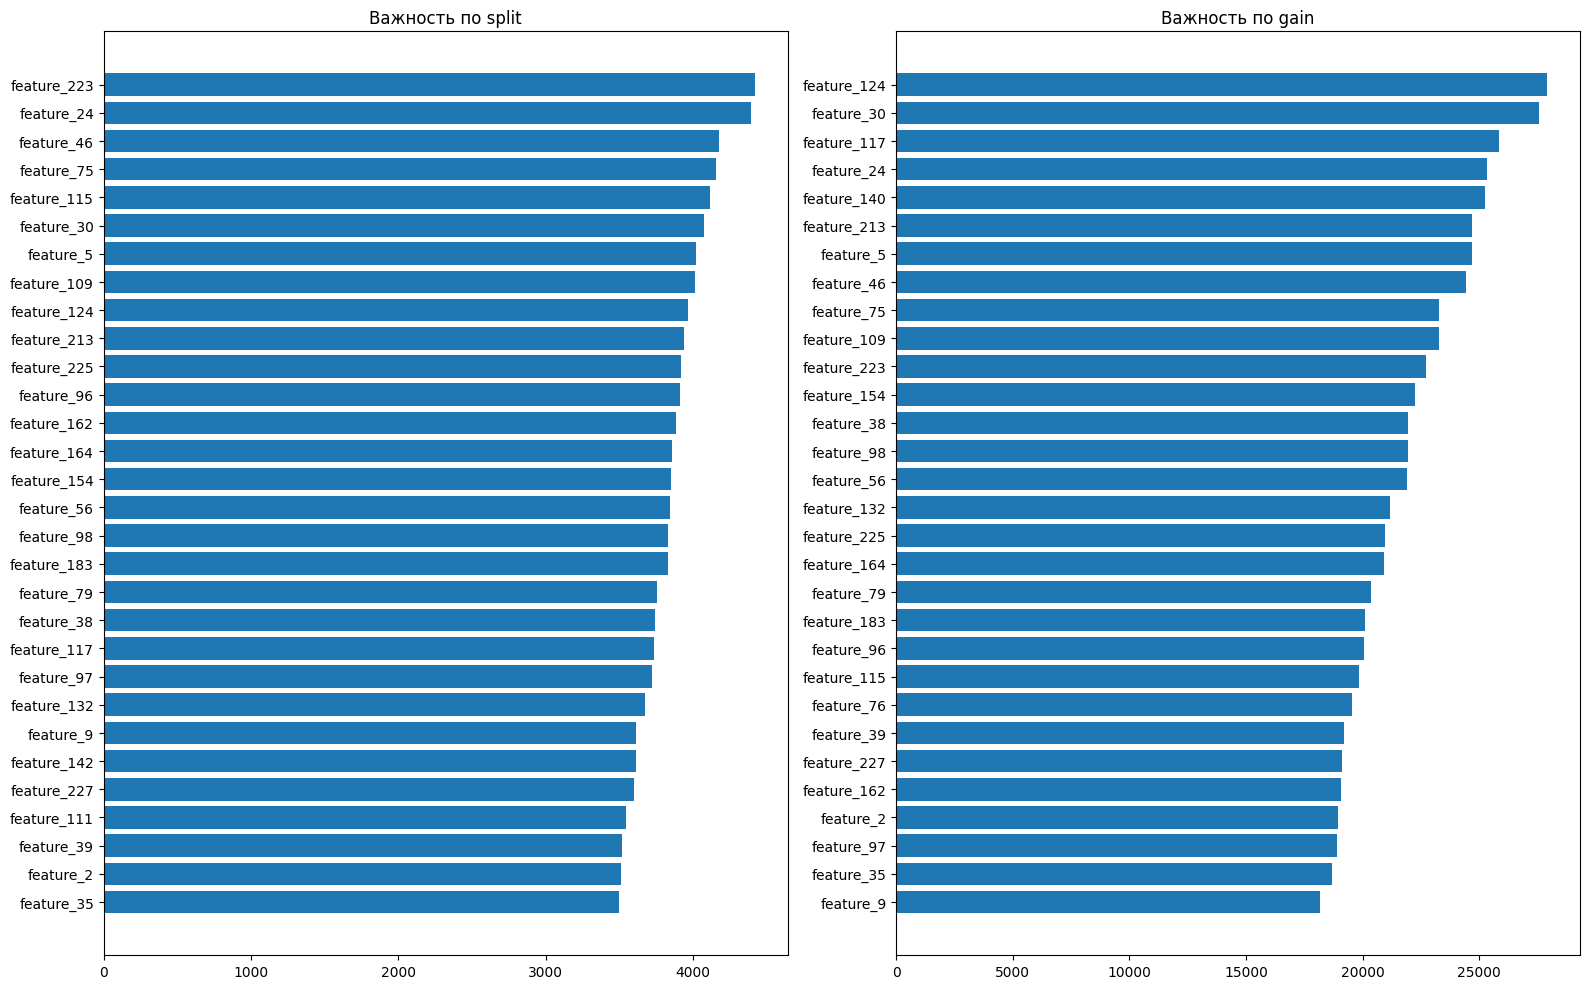

In [16]:
model_imp = lgb.train(
    {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt',
     'random_state': RANDOM_STATE, **study.best_params},
    train_set,
    num_boost_round=1000,
    valid_sets=[valid_set],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

imp_split = pd.Series(model_imp.feature_importance(importance_type='split'), index=model_imp.feature_name()).sort_values().tail(30)
imp_gain = pd.Series(model_imp.feature_importance(importance_type='gain'), index=model_imp.feature_name()).sort_values().tail(30)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
axes[0].barh(imp_split.index, imp_split.values)
axes[0].set_title('Важность по split')
axes[1].barh(imp_gain.index, imp_gain.values)
axes[1].set_title('Важность по gain')
plt.tight_layout()
plt.show()

**Вопрос:** Какие выводы можно сделать из полученных графиков?

Гистограмма важности признаков по split и gain для бустинга говорит о том, что оба показателя в ТОПах расходятся. Например, feature_223 стоит 1-ым по split, но по gain он только 9-ый, а feature_124 наоборот, по split лишь 6-ой, зато по gain уверенно первый. То же самое с feature_117, по числу разбиений он совсем внизу, а по вкладу в качество 3-ий. Split считает, сколько раз модель резала по фиче, и по нему в ТОП попадают признаки с большим числом уникальных значений, по которым вполне удобно резать. Gain показывает, сколько прироста качества эти разбиения на деле дали. Ещё видно, что на обоих графиках столбцы постепенно убывают, значит модель достаточно устойчива.

# Логрег

## plot_metric_time (1 балл)

**Задание:** Реализуйте функцию plot_metric_time, которая будет принимать на вход четыре аргумента, а именно: 
- массив значений фичи, 
- массив значений таргета,
- массив времени (аггрегированного по месяцам или кварталам, то есть `month` или `quarter` в вашей задаче, по дням рисовать не надо),
- метрику, которую необходимо отрисовать (нужно реализовать функцию для двух метрик: `IV` и `roc_auc`)
- число бакетов для вычисления `IV`, если выбрана эта метрика

Можете добваить какие-то ещё аргументы, если вам нужно

Если в фиче есть пропуски, функция должна убирать строки с пропусками из рассмотрения

**Hint**: можно, конечно, реализовать эту функцию через цикл, а можно попробовать разобраться и реализовать её через пандасовские `groupby` -> `apply`, это изящнее и быстрее

In [17]:
import plotly.graph_objects as go

In [18]:
def plot_metric_time(
        values: pd.Series,
        target: pd.Series,
        time: pd.Series,
        metric: str = 'IV',
        n_buckets_for_IV: int = 15,
        feature_name: str = None,      
        is_categorical: bool = False,  
) -> go.Figure:

    feature_name = feature_name or values.name or 'feature'

    data = pd.DataFrame({'feature': values, 'target': target, 'time': time})
    data = data.dropna(subset=['feature'])  

    if metric == 'IV':
        metric_by_time = data.groupby('time').apply(
            lambda g: calc_iv(g, 'feature', 'target', n_buckets=n_buckets_for_IV, is_categorical=is_categorical)
        )
    elif metric == 'roc_auc':
        metric_by_time = data.groupby('time').apply(
            lambda g: roc_auc_score(g['target'], g['feature'])
        )
    else:
        raise NotImplementedError("only 'IV' and 'roc_auc' metrics are implemented")

    metric_by_time = metric_by_time.sort_index()

    plot_title = f'{feature_name}, {metric} in time'
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=metric_by_time.index,
            y=metric_by_time.values,
            mode='markers+lines',
            name=feature_name,
        ))
    fig.update_layout(
            title_text=plot_title,
            yaxis=dict(title=metric),
            width=1000,
            height=450,
            xaxis=dict(
                domain=[0, .95],
                showgrid=True,
                tickvals=metric_by_time.index,
            ),
            margin=dict(l=30, r=30, b=30, t=50),
            )
    fig.show()

    return fig

Я добавила 2 аргумента: feature_name, он подходит для заголовка графика и is_categorical как флаг, так как IV я считала ранее по-разному для числовых и категориальных фичей.

In [78]:
plot_metric_time(df['feature_15'], df[TARGET], df['quarter'], metric='roc_auc', feature_name='feature_15');

/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


Как можно увидеть на графике, roc auc лежит от 0.46 до 0.472, то есть сырое значение feature_15 почти не разделяет таргет. Можно сказать, что он слабый предиктор. Ещё значения по всему диапазону ниже 0.5, связь с таргетом обратная. То есть чем больше feature_15, тем в среднем ближе таргет к нулю. По времени признак ведёт себя стабильно, не деградирует. Можно только в июле 2022 заметить провал до 0.46. Хотя после auc возвращается на прежний уровень. Так как масштаб небольшой 0.012, такой провал скорее шум одного квартала, чем настоящее изменение признака.

In [19]:
# примерно так это должно будет выглядеть
#plot_metric_time(df[...], df['target'], df['quarter']) 

**Задание:** Возьмите **топ-15** фичей получившегося бустинга по важности по `gain`. Отрисуйте для них графики стабильности по `IV` во времени и удалите из рассмотрения те признаки, качество которых деградирует

**NB!** Обращайте внимание на масштаб оси *y!* Иногда признак стабильнее, чем кажется)

Если вам это мешает, можете поменять ось *y*, чтобы она начиналась от нуля в прошлом задании.

In [20]:
best_params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': RANDOM_STATE,
    **study.best_params,   
}

model = lgb.train(
    best_params,
    train_set,
    num_boost_round=1000,
    valid_sets=[valid_set],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

gain_importance = pd.Series(
    model.feature_importance(importance_type='gain'),
    index=model.feature_name()
).sort_values(ascending=False)

top15_by_gain = gain_importance.head(15).index.tolist()
print('Топ-15 фичей по gain:')
print(gain_importance.head(15))

Топ-15 фичей по gain:
feature_124    27924.669791
feature_30     27561.093455
feature_117    25830.252759
feature_24     25318.318693
feature_140    25250.101284
feature_213    24699.678633
feature_5      24675.404687
feature_46     24433.430973
feature_75     23288.213942
feature_109    23257.074689
feature_223    22732.923252
feature_154    22226.223085
feature_38     21965.870734
feature_98     21952.474916
feature_56     21887.855454
dtype: float64


Здесь я сначала дообучаю финальную модель на лучших параметрах из Optuna и беру топ-15 фичей.

In [21]:
for feature in top15_by_gain:
    plot_metric_time(df[feature], df[TARGET], df['quarter'], metric='IV', n_buckets_for_IV=15)

/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


...

/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


Просмотрела все 15 фич по графикам, удалю 4 штуки: feature_30, feature_117, feature_154, feature_38. У всех наблюдается доставточно направленное падение IV к концу периода, а не случайный шумовой провал.

In [22]:
degrading_features = ['feature_30', 'feature_117', 'feature_154', 'feature_38']

top15features_stable = [f for f in top15_by_gain if f not in degrading_features]
print(f'Убираю {len(degrading_features)} , так как это деградирующие фичи: {degrading_features}')
print(f'Итого осталось {len(top15features_stable)} нормальных фич: {top15features_stable}')

Убираю 4 , так как это деградирующие фичи: ['feature_30', 'feature_117', 'feature_154', 'feature_38']
Итого осталось 11 нормальных фич: ['feature_124', 'feature_24', 'feature_140', 'feature_213', 'feature_5', 'feature_46', 'feature_75', 'feature_109', 'feature_223', 'feature_98', 'feature_56']


На этом моменте предлагаю сделать новый маленький датафрейм, чтобы не "портить" исходный

И проводить все манипуляции с фичами на нём

In [23]:
df_for_logreg = df[top15features_stable + ['date', 'month', 'quarter', 'target', 'sample_part']].copy()

## Предобработка признаков (3 балла)

**Задание:** Используя функицю woe_line из ДЗ по логрегу, проверьте **числовые** фичи из полученного списка фичей на линейность по WoE на трейн-выборке (если в фиче есть пропуски - дропаем их при отрисовке)

Если фичи нелинейные, **линеаризуйте их**.

Преобразования, которые можно/стоит пробовать:
- клипы (`np.clip`) - зачастую их достаточно
- корень
- квадрат
- логарифм

Если нужно, можно прибавлять к фиче константу или менять её знак

При желании можно "распилить фичу на две половины" (если она немонотонна) и линеаризовать их по отдельности

Однако слишком упираться в линеаризацию фичей не нужно. Если фича ну совсем никак не линеаризуется, в крайнем случае можно её дропнуть или оставить как есть.

При отрисовке можно ограничиться 15-20 бактеами

In [24]:
import scipy.stats as sps
from scipy.special import logit
from sklearn.linear_model import LogisticRegression

def calc_buckets(x, n_buckets):
    x = pd.Series(x).reset_index(drop=True)
    buckets = x.rank(method="dense", pct=True) * n_buckets
    buckets = np.ceil(buckets) - 1
    return np.array(buckets, dtype=np.int16)

def woe_transform(badrate, offset):
    return logit(badrate) - offset

def woe_ci(target, buckets, offset):
    target = np.array(target)
    all_buckets = np.array(buckets)
    n_buckets = all_buckets.max() + 1
    z = sps.norm.ppf(0.975)
    badrate = np.zeros(n_buckets)
    badrate_lower = np.zeros(n_buckets)
    badrate_upper = np.zeros(n_buckets)
    for i in range(n_buckets):
        y = target[all_buckets == i]
        n = len(y)
        p_hat = y.mean()
        center = (p_hat + z**2 / (2 * n)) / (1 + z**2 / n)
        indent_c = (z / (1 + z**2 / n)) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
        badrate[i] = p_hat
        badrate_lower[i] = center - indent_c
        badrate_upper[i] = center + indent_c
    woe = woe_transform(badrate, offset)
    woe_lower = woe_transform(badrate_lower, offset)
    woe_upper = woe_transform(badrate_upper, offset)
    return pd.Series(woe), pd.Series(woe_lower), pd.Series(woe_upper)

def calc_line(values, target, mean_feature, offset):
    model = LogisticRegression()
    model.fit(values.reshape(-1, 1), target)
    proba = model.predict_proba(mean_feature.reshape(-1, 1))[:, 1]
    return woe_transform(proba, offset)

def calc_buckets_info(values, target, buckets):
    n_buckets = buckets.max() + 1
    mean_feature = np.array([values[buckets == i].mean() for i in range(n_buckets)])
    offset = logit(target.mean())
    line = calc_line(values, target, mean_feature, offset)
    woe, woe_lower, woe_upper = woe_ci(target, buckets, offset)
    return {"mean_feature": mean_feature, "line": line, "woe": woe, "woe_lower": woe_lower, "woe_upper": woe_upper}

def calc_plot_title(values, target, buckets):
    auc = roc_auc_score(target, values)
    n_buckets = buckets.max() + 1
    B = target.sum()
    G = len(target) - B
    offset = logit(target.mean())
    woe, _, _ = woe_ci(target, buckets, offset)
    woe = np.array(woe)
    IV = 0.0
    for i in range(n_buckets):
        y_i = target[buckets == i]
        B_i = y_i.sum()
        G_i = len(y_i) - B_i
        IV += (B_i / B - G_i / G) * woe[i]
    mean_feature = np.array([values[buckets == i].mean() for i in range(n_buckets)])
    weights = np.array([(buckets == i).sum() for i in range(n_buckets)])
    x_mean = np.average(mean_feature, weights=weights)
    y_mean = np.average(woe, weights=weights)
    covari_xy = np.average((mean_feature - x_mean) * (woe - y_mean), weights=weights)
    vari_x = np.average((mean_feature - x_mean) ** 2, weights=weights)
    vari_y = np.average((woe - y_mean) ** 2, weights=weights)
    R_sqr = covari_xy ** 2 / (vari_x * vari_y)
    return f"AUC = {auc:.3f} IV = {IV:.3f} R_sqr = {R_sqr:.3f} "

def make_figure(buckets_info, plot_title):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=buckets_info["mean_feature"], y=buckets_info["line"], mode='lines', name="interpolation_line", showlegend=False))
    fig.add_trace(go.Scatter(
        x=buckets_info["mean_feature"], y=buckets_info["woe"],
        line=dict(color='firebrick', width=1, dash='dot'),
        error_y=dict(type='data', symmetric=False, array=buckets_info["woe_upper"], arrayminus=buckets_info["woe_lower"]),
        name="WoE", showlegend=False
    ))
    fig.update_layout(
        width=1000, height=450,
        xaxis_title=dict(text='Feature value', font=dict(size=12)),
        yaxis_title=dict(text="WoE", font=dict(size=12)),
        title=dict(text=plot_title, y=0.95, x=0.5, font=dict(size=12), xanchor="center", yanchor="top"),
        margin=go.layout.Margin(l=50, r=50, b=50, t=60),
    )
    return fig

def woe_line(values, target, n_buckets):
    buckets = calc_buckets(values, n_buckets)
    buckets_info = calc_buckets_info(values, target, buckets)
    plot_title = calc_plot_title(values, target, buckets)
    return make_figure(buckets_info, plot_title)

In [25]:
df_train_logreg = df_for_logreg[df_for_logreg['sample_part'] == 'train']

numeric_features = [f for f in top15features_stable if df_train_logreg[f].dtype != 'category']

for feature in numeric_features:
    sub = df_train_logreg[[feature, TARGET]].dropna(subset=[feature])
    fig = woe_line(values=sub[feature].values, target=sub[TARGET].values, n_buckets=15)
    fig.show()

Вообще среди топ-15 фичей не было категориальных, только числовые, но я на всякий случай фильтрую только числовые.

Как видно, большая часть фичей, а именно feature_124 (R² = 0.875), feature_24 (0.956), feature_140 (0.855), feature_75 (0.962), feature_223 (0.946), feature_98 (0.981) уже линейны по WoE, преобразовывать их не нужно. Ещё 2 фичи: feature_5 (0.671) и feature_109 (0.754). Они пограничные, но лучше оставить их как есть, чтобы не упираться в линеаризацию фичей. Три фичи потребуют преобразований: feature_213 (R² = 0.487, это самый слабый результат), тут попробуем клип по квантилям от 0.02 до 0.98, и ещё клип сделаю для feature_46 (у него R² = 0.641). И feature_56 (его R² = 0.756), но тут клип не подходит. Клип бы срезал хвост в константу вместо сжатия масштаба, поэтому вместо него применяем знако-сохраняющий логарифм.

In [26]:
for feature in ['feature_213', 'feature_46']:
    lower, upper = df_train_logreg[feature].quantile([0.02, 0.98])
    clipped = df_train_logreg[feature].clip(lower, upper)

    sub = pd.DataFrame({feature: clipped, TARGET: df_train_logreg[TARGET]}).dropna(subset=[feature])
    fig = woe_line(values=sub[feature].values, target=sub[TARGET].values, n_buckets=15)
    fig.show()

In [27]:
feature_56_transf = np.sign(df_train_logreg['feature_56']) * np.log1p(np.abs(df_train_logreg['feature_56']))

sub = pd.DataFrame({'feature_56_transf': feature_56_transf, TARGET: df_train_logreg[TARGET]}).dropna(subset=['feature_56_transf'])
fig = woe_line(values=sub['feature_56_transf'].values, target=sub[TARGET].values, n_buckets=15)
fig.show()

На удивление, ни одно из 3 преобразований не сработало. Клип на feature_213 и feature_46 дал либо нулевой эффект по линейности ценой заметной потери IV, либо ухудшение. А sign-log на feature_56 сделал фичу хуже по обоим показателям сразу. Таким образом, лучше оставить feature_213, feature_46 и feature_56 в исходном, непреобразованном виде. Конечно, они не идеально линейны, но это лучше, чем при попытки их выпрямить.

Пришло время заполнить пропуски.

Самый простой вариант для числовых признаков - заполнить их средним значением фичи

**Вопрос**: какие проблемы могут возникнуть при таком заполнении пропусков?

**Задание**: Проверьте, что заполнение средним значением адекватно для тех признаков, где есть пропуски (hint: в нашем датасете - почти всегда адекватно). Если нет, придумайте, как ещё можно заполнить пропуски. Ну и заполните их)

In [28]:
missing_share = df_train_logreg[numeric_features].isna().mean()
features_with_na = missing_share[missing_share > 0].index.tolist()
print('Фичи с пропусками:', features_with_na)

for feature in features_with_na:
    is_na = df_train_logreg[feature].isna()
    badrate_missing = df_train_logreg.loc[is_na, TARGET].mean()
    badrate_present = df_train_logreg.loc[~is_na, TARGET].mean()
    print(f'{feature}: доля пропусков={is_na.mean():.3f}, badrate с пропуском={badrate_missing:.3f}, badrate без пропуска={badrate_present:.3f}')

Фичи с пропусками: ['feature_124', 'feature_140', 'feature_223']
feature_124: доля пропусков=0.118, badrate с пропуском=0.708, badrate без пропуска=0.709
feature_140: доля пропусков=0.074, badrate с пропуском=0.706, badrate без пропуска=0.710
feature_223: доля пропусков=0.147, badrate с пропуском=0.708, badrate без пропуска=0.709


Как видно, у всех 3 фичей с пропусками feature_124, feature_140 и feature_223 badrate при пропуске и без пропуска отличаются всего на тысячные (0.708 и 0.709, 0.706 и 0.710, 0.708 и 0.709). Такая разница в пределах шума, то есть факт пропуска никакой информации про таргет не несёт, и заполнение средним для всех 3 адекватно.

При заполнении средним пропусков смещается распределение фичи. Снижается дисперсия, а из-за этого может занижаться её предсказательная сила. А также, могут просесть IV и WoE. Если же пропуски не случайны, а какая-то связь с таргетом есть, то среднее эту связь просто сотрёт. И среднее плохо работает, если у фичи тяжёлые выбросы или скошенное распределение. В таком случае, среднее не выглядит как типичное значение фичи, и заполнение им искажает данные сильнее, чем удаление вообще.

In [29]:
for feature in features_with_na:
    fill_value = df_train_logreg[feature].mean()
    df_for_logreg[feature] = df_for_logreg[feature].fillna(fill_value)
    print(f'{feature}: заполнено средним по трейну = {fill_value:.3f}')

feature_124: заполнено средним по трейну = -42.006
feature_140: заполнено средним по трейну = 30.856
feature_223: заполнено средним по трейну = 126.160


Вспомним про категориальные признаки, их нужно закодировать.

**Задание:** Используя `OneHotEncoder` закодируйте категориальные признаки.

In [30]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [f for f in top15features_stable if df_for_logreg[f].dtype == 'category']
print('Категориальные фичи среди отобранных 11:', categorical_features)

if categorical_features:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder.fit(df_train_logreg[categorical_features])

    encoded = pd.DataFrame(
        encoder.transform(df_for_logreg[categorical_features]),
        columns=encoder.get_feature_names_out(categorical_features),
        index=df_for_logreg.index
    )
    df_for_logreg = pd.concat([df_for_logreg.drop(columns=categorical_features), encoded], axis=1)
else:
    print('Категориальных фичей среди ТОП-15 нет.')

Категориальные фичи среди отобранных 11: []
Категориальных фичей среди ТОП-15 нет.


Всего категориальных фичей в датасете 2 feature_0 и feature_209, но сейчас я работаю с категориальными признаками именно внутри df_for_logreg по заданию. А они не входят в топ-15 по gain. Значит модель так распределила важность по итогам обучения на трейне и ничего кодировать не надо. Их в мини датасете нет.

## Stepwise и обучение логрега (5 баллов)

**Задание (boss)**: Реализуйте Stepwise-алгоритм.

Ваша функция `stepwise` должна принимать на вход:
- Датафрейм со всеми признаками и таргетом
- список с именами рассматриваемых признаков
- строку-имя таргета
- уровни значимости `alpha_in` и `alpha_out`

И возвращать список отобранных признаков.

Во время работы пусть она также выводит, какой признак был включён или исключён и с каким `p-value`

In [31]:
from scipy.stats.distributions import chi2
from sklearn.metrics import log_loss

In [32]:
def likelihood_ratio_test(ll_short, ll_long):

    lr = 2 * (ll_short - ll_long)
    return chi2.sf(lr, 1)

def ready_ll(data, feats, target):
    y = data[target].values
    if len(feats) == 0:
        p = np.clip(y.mean(), 1e-10, 1 - 1e-10)
        preds = np.full(len(y), p)
    else:
        model = LogisticRegression(C=np.inf, max_iter=2000)
        model.fit(data[feats], y)
        preds = model.predict_proba(data[feats])[:, 1]
    
    return log_loss(y, preds, normalize=False)

Я оставила lr = 2 * (ll_short - ll_long) как есть и убрала минус у log_loss, чтобы всё правильно считалось.

In [33]:
def stepwise(
        df: pd.DataFrame, 
        features: list[str], 
        target: str, 
        alpha_in: float = 0.01, 
        alpha_out:  float = 0.05
        ) -> list[str]:
    

    selected_features = list()

    while True:

        p_value = None
        best_feature = None
        if (len(selected_features) < len(features)):

            ll_short = ready_ll(df, selected_features, target)
            remaining = [f for f in features if f not in selected_features]

            best_p_value, best_var = None, None
            for var in remaining:
                ll_long = ready_ll(df, selected_features + [var], target)
                candidate_p_value = likelihood_ratio_test(ll_short, ll_long)
                if best_p_value is None or candidate_p_value < best_p_value:
                    best_p_value, best_var = candidate_p_value, var

            if best_p_value is not None and best_p_value < alpha_in:
                best_feature, p_value = best_var, best_p_value


            if best_feature:
                selected_features.append(best_feature)
                print(f"В модель была добавлена переменная {best_feature}, p-value: {round(p_value, 6)}")
                

        worst_feature = None
        if (len(selected_features) > 1):

            ll_full = ready_ll(df, selected_features, target)

            worst_p_value, worst_candidate = None, None
            for var in selected_features:
                remaining_features = [f for f in selected_features if f != var]
                ll_without = ready_ll(df, remaining_features, target)
                candidate_p_value = likelihood_ratio_test(ll_without, ll_full)
                if worst_p_value is None or candidate_p_value > worst_p_value:
                    worst_p_value, worst_candidate = candidate_p_value, var

            if worst_p_value is not None and worst_p_value > alpha_out:
                worst_feature, p_value = worst_candidate, worst_p_value
            

            if worst_feature:
                selected_features.remove(worst_feature)
                print(f"Из модели была удалена переменная {worst_feature}, p-value: {round(p_value, 6)}")

        if not (best_feature or worst_feature):
            break 

    return selected_features

Запустите ваш алгоритм на отобранных фичах со значениями `alpha_in = 0.01`, `alpha_out = 0.02`

Если в степвайз заходят *все переменные*, причём с очень маленькими `p-value` - это неудивительно, ведь вы уже провели серьёзный предварительный отбор фичей.

Чтобы убедиться в коректности работы своего алгоритма, можете попробовать запустить его на каких-нибудь других фичах, откинутых сильно ранее

Добавлю, чтобы не было слишком много варнингов, а то не читаемо.

In [46]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [48]:
woe_cols = df_train_logreg[top15features_stable]
nan_report = woe_cols.isna().sum()
print(nan_report[nan_report > 0])

Series([], dtype: int64)


In [49]:
selected_features = stepwise(df_train_logreg, top15features_stable, TARGET, alpha_in=0.01, alpha_out=0.02)

В модель была добавлена переменная feature_124, p-value: 0.0
В модель была добавлена переменная feature_140, p-value: 0.0
В модель была добавлена переменная feature_24, p-value: 0.0
В модель была добавлена переменная feature_98, p-value: 0.0
В модель была добавлена переменная feature_213, p-value: 0.0
В модель была добавлена переменная feature_109, p-value: 0.0
В модель была добавлена переменная feature_75, p-value: 0.0
В модель была добавлена переменная feature_223, p-value: 0.0
В модель была добавлена переменная feature_56, p-value: 0.0
В модель была добавлена переменная feature_46, p-value: 0.0
В модель была добавлена переменная feature_5, p-value: 0.0


In [52]:
print(selected_features)

['feature_124', 'feature_140', 'feature_24', 'feature_98', 'feature_213', 'feature_109', 'feature_75', 'feature_223', 'feature_56', 'feature_46', 'feature_5']


In [54]:
sanity_feature = iv_numeric.idxmin()
print('Фича для проверки:', sanity_feature, '| IV =', round(iv_numeric[sanity_feature], 5))

Фича для проверки: feature_179 | IV = 0.0


In [55]:
sanity_values = df.loc[df_train_logreg.index, sanity_feature]
fill_value = sanity_values.mean()
sanity_values = sanity_values.fillna(fill_value)

df_train_sanity = df_train_logreg.copy()
df_train_sanity[sanity_feature] = sanity_values

In [76]:
sanity_result = stepwise(df_train_sanity, top15features_stable + [sanity_feature], TARGET, alpha_in=0.01, alpha_out=0.02)

if sanity_feature in sanity_result:
    print(f'{sanity_feature} прошла в модель, плохо')
else:
    print(f'{sanity_feature} не прошла отбор, значит алгоритм корректно отфильтровал')

В модель была добавлена переменная feature_124, p-value: 0.0
В модель была добавлена переменная feature_140, p-value: 0.0
В модель была добавлена переменная feature_24, p-value: 0.0
В модель была добавлена переменная feature_98, p-value: 0.0
В модель была добавлена переменная feature_213, p-value: 0.0
В модель была добавлена переменная feature_109, p-value: 0.0
В модель была добавлена переменная feature_75, p-value: 0.0
В модель была добавлена переменная feature_223, p-value: 0.0
В модель была добавлена переменная feature_56, p-value: 0.0
В модель была добавлена переменная feature_46, p-value: 0.0
В модель была добавлена переменная feature_5, p-value: 0.0
feature_179 не прошла отбор, значит алгоритм корректно отфильтровал


Я как раз решила убедиться в коректности работы своего алгоритма и попробовала запустить его на других фичах, откинутых сильно ранее. Всё сработало.

**Задание**: На получившемся наборе признаков обучим, наконец, логрег!

Для обучения можно использовать трейн + валидацию вместе, либо просто трейн

*Не забудьте отскалировать фичи*

In [56]:
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from scipy.special import logit

In [57]:

train_mask = df_for_logreg['sample_part'].isin(['train', 'val'])

X_train = df_for_logreg.loc[train_mask, selected_features]
y_train = df_for_logreg.loc[train_mask, TARGET]

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_all_scaled = scaler.transform(df_for_logreg[selected_features])

logreg = LogisticRegression(penalty=None)
logreg.fit(X_train_scaled, y_train)

df_for_logreg['logreg'] = logreg.predict_proba(X_all_scaled)[:, 1]
df_for_logreg['logit_logreg'] = logit(df_for_logreg['logreg'])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


**Задание:** Оцените качество получившегося логрега **на тестовой выборке** по метрике `roc_auc`. 

**Ваша задача - побить** `threshold_auc = 0.622`. Если этого сделать ну совсем не получается, попробуйте добавить в модель ещё переменных (но должно получаться :)

**Также:**

- Постройте графики линейности по WoE получившегося логрега на трейне и тестовой выборке (оценивайте линейность для `logit_logreg`, а не для вероятности!)
- Постройте график стабильности `roc_auc` во времени для получившегося логрега

In [58]:
threshold_auc = 0.622

test_mask = df_for_logreg['sample_part'] == 'test'
test_auc = roc_auc_score(df_for_logreg.loc[test_mask, TARGET], df_for_logreg.loc[test_mask, 'logreg'])

print(f'ROC_AUC на тесте: {test_auc:.4f}')
print(f'Порог: {threshold_auc}')
print('Порог прошли' if test_auc > threshold_auc else 'Порог не прошли')

ROC_AUC на тесте: 0.5981
Порог: 0.622
Порог не прошли


In [59]:
train_data = df_for_logreg[df_for_logreg['sample_part'] == 'train']
test_data = df_for_logreg[df_for_logreg['sample_part'] == 'test']

fig_train = woe_line(values=train_data['logit_logreg'].values, target=train_data[TARGET].values, n_buckets=15)
fig_train.show()

fig_test = woe_line(values=test_data['logit_logreg'].values, target=test_data[TARGET].values, n_buckets=15)
fig_test.show()

In [60]:
fig_stability = plot_metric_time(
    df_for_logreg['logreg'], df_for_logreg[TARGET], df_for_logreg['quarter'],
    metric='roc_auc', feature_name='logreg'
)
fig_stability.show()

/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


Попробую построить по-другому, чтобы преодолеть трешхолд.

In [61]:
df_for_logreg_wide = df[select_features + ['date', 'month', 'quarter', TARGET, 'sample_part']].copy()
df_train_wide = df_for_logreg_wide[df_for_logreg_wide['sample_part'] == 'train']

numeric_wide = [f for f in select_features if df_train_wide[f].dtype != 'category']
categorical_wide = [f for f in select_features if df_train_wide[f].dtype == 'category']

features_with_na_wide = [f for f in numeric_wide if df_train_wide[f].isna().any()]
for feature in features_with_na_wide:
    fill_value = df_train_wide[feature].mean()
    df_for_logreg_wide[feature] = df_for_logreg_wide[feature].fillna(fill_value)
df_train_wide = df_for_logreg_wide[df_for_logreg_wide['sample_part'] == 'train']

if categorical_wide:
    encoder_wide = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder_wide.fit(df_train_wide[categorical_wide])
    encoded_wide = pd.DataFrame(
        encoder_wide.transform(df_for_logreg_wide[categorical_wide]),
        columns=encoder_wide.get_feature_names_out(categorical_wide),
        index=df_for_logreg_wide.index
    )
    df_for_logreg_wide = pd.concat([df_for_logreg_wide.drop(columns=categorical_wide), encoded_wide], axis=1)
    wide_candidates = numeric_wide + list(encoder_wide.get_feature_names_out(categorical_wide))
else:
    wide_candidates = numeric_wide

df_train_wide = df_for_logreg_wide[df_for_logreg_wide['sample_part'] == 'train']
print(f'Варианты для stepwise: {len(wide_candidates)} (было {len(top15features_stable)})')

Варианты для stepwise: 62 (было 11)


In [63]:
train_mask_wide = df_for_logreg_wide['sample_part'].isin(['train', 'val'])
X_train_wide = df_for_logreg_wide.loc[train_mask_wide, selected_features_wide]
y_train_wide = df_for_logreg_wide.loc[train_mask_wide, TARGET]

scaler_wide = StandardScaler()
scaler_wide.fit(X_train_wide)
X_train_wide_scaled = scaler_wide.transform(X_train_wide)
X_all_wide_scaled = scaler_wide.transform(df_for_logreg_wide[selected_features_wide])

logreg_wide = LogisticRegression(penalty=None)
logreg_wide.fit(X_train_wide_scaled, y_train_wide)
df_for_logreg_wide['logreg'] = logreg_wide.predict_proba(X_all_wide_scaled)[:, 1]

test_mask_wide = df_for_logreg_wide['sample_part'] == 'test'
test_auc_wide = roc_auc_score(df_for_logreg_wide.loc[test_mask_wide, TARGET], df_for_logreg_wide.loc[test_mask_wide, 'logreg'])
print(f'ROC AUC на тесте с новым набором: {test_auc_wide:.4f}, порог {threshold_auc}')
print('Порог пройден' if test_auc_wide > threshold_auc else 'Порог пока что не пройден')

ROC AUC на тесте с новым набором: 0.5960, порог 0.622
Порог пока что не пройден


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Снова не получилось побить трешхолд, поэтому попробую обучить логистическую регрессию на WoE фичей.

In [64]:
def log_WoE(values, target, n_buckets=10):
    edges = np.unique(np.quantile(values.dropna(), np.linspace(0, 1, n_buckets + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    buckets = pd.cut(values, bins=edges, include_lowest=True).astype(str)
    buckets[values.isna()] = 'MISSING'

    stats = pd.DataFrame({'bucket': buckets, 'y': target}).groupby('bucket')['y'].agg(['count', 'sum'])
    stats.columns = ['total', 'bad']
    stats['good'] = stats['total'] - stats['bad']
    bad_total, good_total = stats['bad'].sum(), stats['good'].sum()
    eps = 0.5
    stats['bad_rate'] = (stats['bad'] + eps) / (bad_total + eps * len(stats))
    stats['good_rate'] = (stats['good'] + eps) / (good_total + eps * len(stats))
    stats['woe'] = np.log(stats['good_rate'] / stats['bad_rate'])
    return edges, stats['woe'].to_dict()

def start_WoE(values, edges, woe_map):
    buckets = pd.cut(values, bins=edges, include_lowest=True).astype(str)
    buckets[values.isna()] = 'MISSING'
    return buckets.map(woe_map).fillna(0.0)  

In [65]:
df_woe = df_for_logreg_wide[['date', 'month', 'quarter', TARGET, 'sample_part']].copy()

for ftr in numeric_wide:
    edges, woe_map = log_WoE(df_train_wide[ftr], df_train_wide[TARGET], n_buckets=10)
    df_woe[ftr] = start_WoE(df_for_logreg_wide[ftr], edges, woe_map)

for column in encoder_wide.get_feature_names_out(categorical_wide):
    df_woe[column] = df_for_logreg_wide[column]

df_train_woe = df_woe[df_woe['sample_part'] == 'train']
woe_vars = numeric_wide + list(encoder_wide.get_feature_names_out(categorical_wide))

In [66]:
selected_features_woe = stepwise(df_train_woe, woe_vars, TARGET, alpha_in=0.01, alpha_out=0.02)
print('По WoE:', len(selected_features_woe))

В модель была добавлена переменная feature_114, p-value: 0.0
В модель была добавлена переменная feature_117, p-value: 0.0
В модель была добавлена переменная feature_30, p-value: 0.0
В модель была добавлена переменная feature_124, p-value: 0.0
В модель была добавлена переменная feature_140, p-value: 0.0
В модель была добавлена переменная feature_154, p-value: 0.0
В модель была добавлена переменная feature_79, p-value: 0.0
В модель была добавлена переменная feature_138, p-value: 0.0
В модель была добавлена переменная feature_183, p-value: 0.0
В модель была добавлена переменная feature_15, p-value: 0.0
В модель была добавлена переменная feature_223, p-value: 0.0
В модель была добавлена переменная feature_109, p-value: 0.0
В модель была добавлена переменная feature_12, p-value: 0.0
В модель была добавлена переменная feature_24, p-value: 0.0
В модель была добавлена переменная feature_76, p-value: 0.0
В модель была добавлена переменная feature_213, p-value: 0.0
В модель была добавлена переме

In [67]:
train_mask_woe = df_woe['sample_part'].isin(['train', 'val'])

X_train_woe = df_woe.loc[train_mask_woe, selected_features_woe]
y_train_woe = df_woe.loc[train_mask_woe, TARGET]

scal_woe = StandardScaler()
scal_woe.fit(X_train_woe)
X_train_woe_scaled = scal_woe.transform(X_train_woe)
X_all_woe_scaled = scal_woe.transform(df_woe[selected_features_woe])

logreg_WoE = LogisticRegression(penalty=None)
logreg_WoE.fit(X_train_woe_scaled, y_train_woe)
df_woe['logreg'] = logreg_WoE.predict_proba(X_all_woe_scaled)[:, 1]

test_mask_WoE = df_woe['sample_part'] == 'test'
test_auc_WoE = roc_auc_score(df_woe.loc[test_mask_WoE, TARGET], df_woe.loc[test_mask_WoE, 'logreg'])

print(f'На тесте roc auc: {test_auc_WoE:.4f}, порог {threshold_auc}')
print('Порог прошли' if test_auc_WoE > threshold_auc else 'Порог всё ещё не прошли :( ')

На тесте roc auc: 0.6498, порог 0.622
Порог прошли


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


В итоге, когда набор фичей был всего 11 штук, roc auc = 0.59. Это конечно линейная модель, но слабая. Потом я увеличила фичи до 60, но roc auc сильно не вырос = 0.596, значит проблема была не в малом количестве фичей. После я решила применить WoE для преобразования фичей. Получается зависимости стали линеаризованными. И степвайз отобрал уже 44 фичи, и последний AUC на тесте вырос до 0.6498, перебив трешхолд = 0.622. Всё-таки получилось преодолеть.

In [68]:
df_woe['logit_logreg'] = logit(df_woe['logreg'])

train_new_woe = df_woe[df_woe['sample_part'] == 'train']
test_new_woe = df_woe[df_woe['sample_part'] == 'test']

fig_train_woe = woe_line(values=train_new_woe['logit_logreg'].values, target=train_new_woe[TARGET].values, n_buckets=15)
fig_train_woe.show()

fig_test_woe = woe_line(values=test_new_woe['logit_logreg'].values, target=test_new_woe[TARGET].values, n_buckets=15)
fig_test_woe.show()

Графики линейности по WoE получившегося логрега на трейне и тестовой выборке с новыми линеаризованными фичами. R² на трейне = 0.929, R² на тесте = 0.938, то есть модель очень линейна. WoE точки достаточно четко лежат на прямой линии. AUC = 0.650 на тесте и IV = 0.308 на тесте. На трейне чуть выше эти метрики (0.663 и 0.372). В общем, модель линейна и вполне стабильна между выборками.

In [69]:
fig_stab_WoE = plot_metric_time(
    df_woe['logreg'], df_woe[TARGET], df_woe['quarter'],
    metric='roc_auc', feature_name='logreg_WoE'
)
fig_stab_WoE.show()

/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_21323/1364536720.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metric_by_time = data.groupby('time').apply(


А это график стабильности roc auc во времени для получившегося логрега по новым фичам WoE. Как видно на графиках, модель вполне стабильна по абсолютному уровню auc. Только во второй половине 2022 года на графике наблюдается снижение. 3 квартала падает. В целом, главное, что трешхолд 0.622 пробит. Возможно стоит понаблюдать за моделью, если тренд продолжится за пределами данного периода.

**Задание:** Визуализируйте важность фичей полученной линейной модели.

In [70]:
import_WoE = pd.Series(logreg_WoE.coef_[0], index=selected_features_woe)
import_WoE = import_WoE.reindex(import_WoE.abs().sort_values(ascending=True).index)

fig_import = go.Figure()
fig_import.add_trace(go.Bar(
    x=import_WoE.values,
    y=import_WoE.index,
    orientation='h',
    marker=dict(color=['crimson' if v < 0 else 'royalblue' for v in import_WoE.values])
))
fig_import.update_layout(
    title_text='Важность WoE-фичей',
    xaxis_title='Коэффициент',
    yaxis_title='Фича',
    width=1000,
    height=max(400, len(import_WoE) * 20),
    margin=dict(l=150, r=50, b=50, t=60),
)
fig_import.show()

По графику важности фичей линейной модели видно, что большинство фичей (42) имеют отрицательный коэффициент. Положительный же только у двух фичей (feature_139, feature_115). На графике они выделены синим. К слову, самая весомая фича feature_124. Её коэффициент более −0.15. В целом наблюдается постепенный спад важности фичей. Резких скачков нет. Можно сделать вывод, что модель скорее устойчивая, не зависит только от одной фичи.

# Бонусная часть (4 балла)

В разделе про бустинг мы обучали `LGBMClassifier` на довольно большом наборе фичей. Их количество можно сократить, при этом не теряя в качестве модели.

За начальный набор признаков можно взять все признаки (все 230) или признаки после отбора по IV.

**Ваша задача:** Отобрать признаки, подобрать оптимальные гиперпараметры и обучить `LGBMClassifier`.

Задание творческое) Можно использовать любые методы отбора признаков / оптимизации гиперпараметров.

**Чем меньше признаков, без ухудшения качества модели – тем лучше.**

In [71]:
bonus = select_features
print(f'варианты: {len(bonus)}')

train_data = df[df['sample_part'] == 'train']
val_data = df[df['sample_part'] == 'val']
test_data = df[df['sample_part'] == 'test']

baseline_params = {
    'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt',
    'random_state': RANDOM_STATE,
    **study.best_params, 
}

baseline_model = lgb.train(
    baseline_params,
    lgb.Dataset(train_data[bonus], label=train_data[TARGET]),
    num_boost_round=1000,
    valid_sets=[lgb.Dataset(val_data[bonus], label=val_data[TARGET])],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

варианты: 60


Для отбора признаков хочу взять шапы (SHAP values). Его часто применяют, он хорошо интерпретируемый, но, конечно, долгий по времени.

In [72]:
import shap

expl = shap.TreeExplainer(baseline_model)
sample_idx = train_data.sample(n=min(20000, len(train_data)), random_state=RANDOM_STATE).index
shap_val = expl.shap_values(train_data.loc[sample_idx, bonus])

shap_importance = pd.Series(np.abs(shap_val).mean(axis=0), index=bonus).sort_values(ascending=False)

In [73]:
sort_features = shap_importance.index.tolist()

result = []
for k in range(5, len(sort_features) + 1, 5):
    feat_k = sort_features[:k]
    model_k = lgb.train(
        baseline_params,
        lgb.Dataset(train_data[feat_k], label=train_data[TARGET]),
        num_boost_round=1000,
        valid_sets=[lgb.Dataset(val_data[feat_k], label=val_data[TARGET])],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    val_pred = model_k.predict(val_data[feat_k], num_iteration=model_k.best_iteration)
    val_auc = roc_auc_score(val_data[TARGET], val_pred)
    result.append({'k': k, 'val_auc': val_auc})
    print(f'top-{k}: val AUC = {val_auc:.4f}')

result_df = pd.DataFrame(result)
best_auc = result_df['val_auc'].max()
tolerance = 0.01
final_k = result_df[result_df['val_auc'] >= best_auc - tolerance]['k'].min()
final_features = sort_features[:final_k]
print(f'Выбираем {final_k} признаков из {len(bonus)} , самый лучший roc auc = {best_auc:.4f}, можно потерять {tolerance}')

top-5: val AUC = 0.5920
top-10: val AUC = 0.6330
top-15: val AUC = 0.6637
top-20: val AUC = 0.6982
top-25: val AUC = 0.7120
top-30: val AUC = 0.7287
top-35: val AUC = 0.7406
top-40: val AUC = 0.7452
top-45: val AUC = 0.7493
top-50: val AUC = 0.7542
top-55: val AUC = 0.7556
top-60: val AUC = 0.7550
Выбираем 45 признаков из 60 , самый лучший roc auc = 0.7556, можно потерять 0.01


Задала допуск (tolerance) = 0.01, не должно уйти слишком много признаков и не должно упасть сильно качество.

Идеи для отбора признаков:

- Воспользоваться методами из модуля `sklearn.feature_selection` (точно можно попробовать RFE). Документация https://scikit-learn.org/stable/modules/feature_selection.html
<!-- - С помощью `BorutaPy` из библиотеки `boruta` (https://towardsdatascience.com/simple-example-using-boruta-feature-selection-in-python-8b96925d5d7a – статья может помочь разобраться с запуском алгоритма (мб не откроется без vpn)) -->
- permutation importance и elimination по нему (https://scikit-learn.org/stable/modules/permutation_importance.html)
- попробовать использовать shap-values

А для оптимизации гиперпараметров возьму RandomizedSearchCV. Он проще и займет меньше времени чем та же оптуна. 

In [74]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

X_tune = pd.concat([train_data[final_features], val_data[final_features]])
y_tune = pd.concat([train_data[TARGET], val_data[TARGET]])
test_fold = [-1] * len(train_data) + [0] * len(val_data)  
ps = PredefinedSplit(test_fold)

param_distributions = {
    'num_leaves': np.arange(10, 200),
    'learning_rate': np.logspace(-2, np.log10(0.2), 50),
    'feature_fraction': np.linspace(0.3, 1.0, 20),
    'bagging_fraction': np.linspace(0.4, 1.0, 20),
    'bagging_freq': np.arange(0, 11),
    'lambda_l1': np.logspace(-8, 2, 50),
    'lambda_l2': np.logspace(-8, 2, 50),
}

random_search = RandomizedSearchCV(
    estimator=LGBMClassifier(objective='binary', verbosity=-1, random_state=RANDOM_STATE, n_estimators=500),
    param_distributions=param_distributions,
    n_iter=50,
    scoring='roc_auc',
    cv=ps,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_search.fit(X_tune, y_tune)

print('Лучшие гиперпараметры:', random_search.best_params_)
print('Лучший roc auc:', random_search.best_score_)

Лучшие гиперпараметры: {'num_leaves': np.int64(155), 'learning_rate': np.float64(0.04901651684480223), 'lambda_l2': np.float64(100.0), 'lambda_l1': np.float64(3.727593720314938), 'feature_fraction': np.float64(1.0), 'bagging_freq': np.int64(5), 'bagging_fraction': np.float64(0.6842105263157895)}
Лучший roc auc: 0.7468568795531811


In [75]:
final_model = LGBMClassifier(objective='binary', verbosity=-1, random_state=RANDOM_STATE, n_estimators=500, **random_search.best_params_)
final_model.fit(train_data[final_features], train_data[TARGET])

test_pred = final_model.predict_proba(test_data[final_features])[:, 1]
test_auc_final = roc_auc_score(test_data[TARGET], test_pred)
print(f'Всего получилось {len(final_features)} фичей, roc auc на тесте = {test_auc_final:.4f}')

Всего получилось 45 фичей, roc auc на тесте = 0.7271


Из 230 начальных фичей после отбора по IV осталось всего 60. Шапы позволили сократить фичи до 45. При этом roc auc упал не сильно. Сначала был 0.7556 на 55 признаках, на всех 60 = 0.7550, то есть на всех 60 фичах качество даже чуть ниже, чем на 55, можно предположить, что часть фичей мешала модели, а на отобранных 45 получилось 0.7493. RandomizedSearchCV на этих 45 фичах дал roc auc = 0.7469, чуть ниже, чем у модели без тюнинга, скорее всего из-за отсутствия ранней остановки в LGBMClassifier. Итоговая модель на тесте показала roc auc = 0.7271. К слову, это определённо выше, чем логрег из основной части (там был = 0.65). Этот результат можно объяснить тем, что бустинг обычно лучше видит нелинейные зависимости. Качество не прям сильно упало, но больше точно количество фичей сокращать не стоит.

Спасибо за домашку! Я прям преисполнилась в выполнении различных манипуляций с переменными!! В дальнейшим это точно ускорит мою работу с обучением моделей и настройкой фичей!

![мем](IMG_5062.JPG)